In [1]:
import pandas as pd

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from google.colab import files

uploaded = files.upload()

Saving WA_Fn-UseC_-HR-Employee-Attrition.csv to WA_Fn-UseC_-HR-Employee-Attrition.csv


In [4]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

In [6]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [7]:
df.tail()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8
1469,34,No,Travel_Rarely,628,Research & Development,8,3,Medical,1,2068,...,1,80,0,6,3,4,4,3,1,2


In [8]:
df.shape

(1470, 35)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [10]:
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


Exploratory Data Analysis

Department-wise Attrition

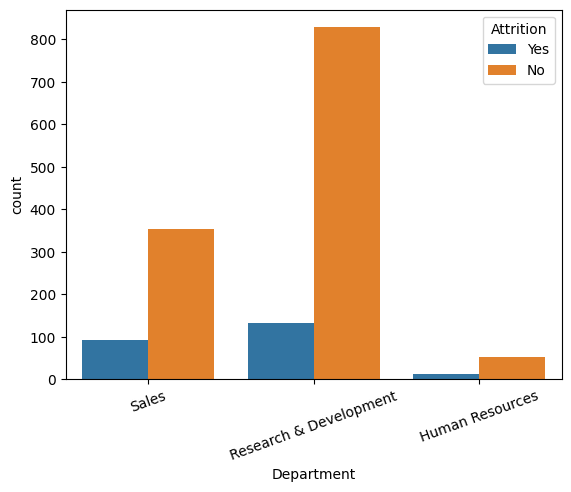

In [13]:
sns.countplot(x="Department", hue="Attrition", data=df)
plt.xticks(rotation=20)
plt.show()

Job Role vs Attrition

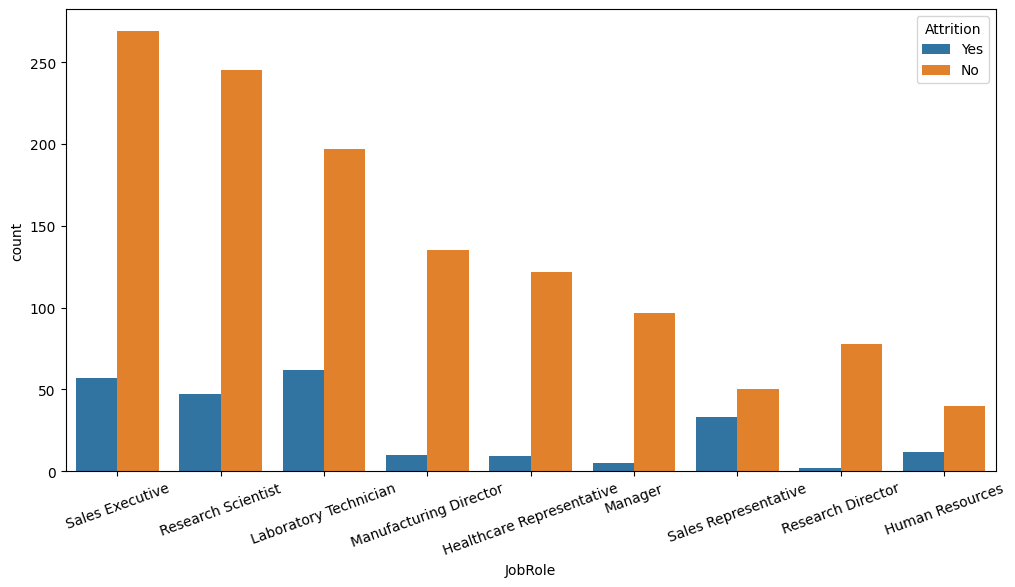

In [14]:
plt.figure(figsize=(12, 6))
sns.countplot(x="JobRole", hue="Attrition", data=df)
plt.xticks(rotation=20)
plt.show()


Gender vs Attrition

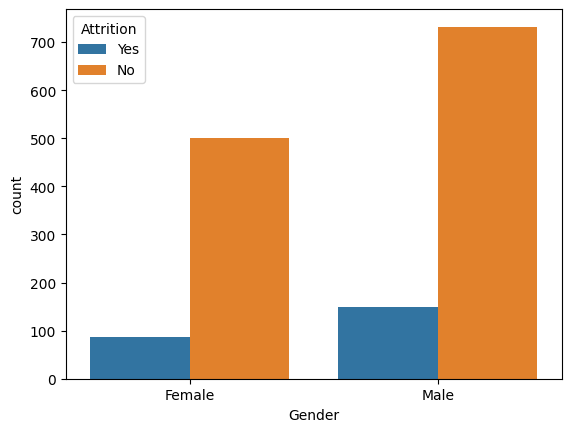

In [15]:
sns.countplot(x="Gender", hue="Attrition", data=df)
plt.show()

Salary vs Attrition

Monthly income

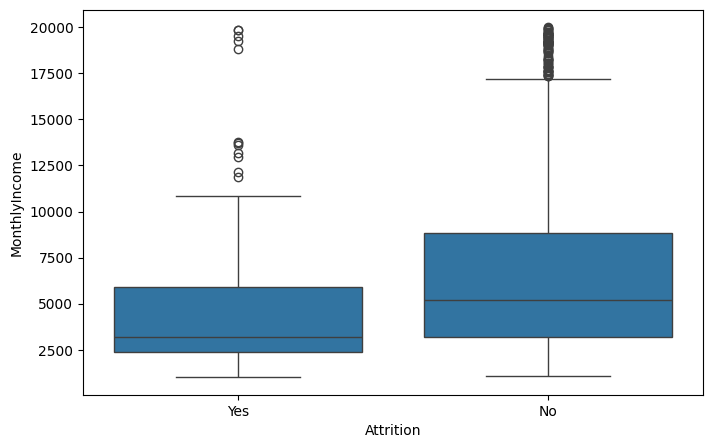

In [16]:
plt.figure(figsize=(8,5))

sns.boxplot(x="Attrition",
            y="MonthlyIncome",
            data=df)

plt.show()

Interpretation:

Do employees with low salary leave more?

Age Distribution

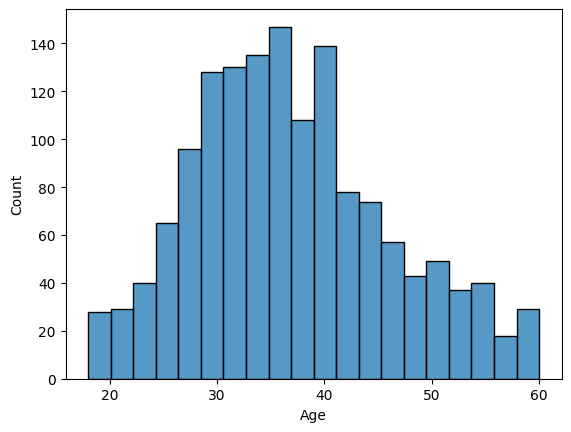

In [17]:
sns.histplot(df["Age"], bins=20)

plt.show()

Promotion Effect

Years Since Last Promotion

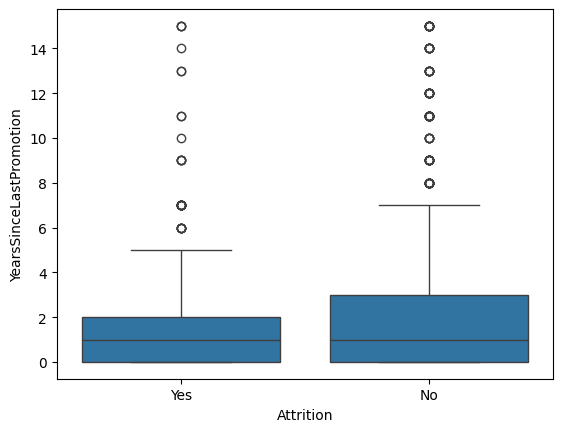

In [18]:
sns.boxplot(x="Attrition",
            y="YearsSinceLastPromotion",
            data=df)

plt.show()

Interpretation:

Employees waiting many years for promotion may resign.

Overtime

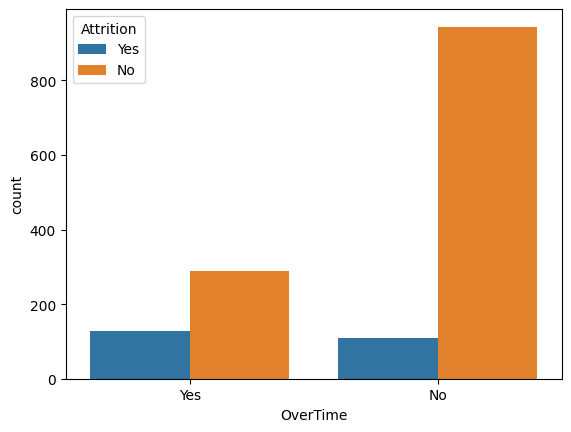

In [19]:
sns.countplot(x="OverTime",
              hue="Attrition",
              data=df)

plt.show()

Marital Status

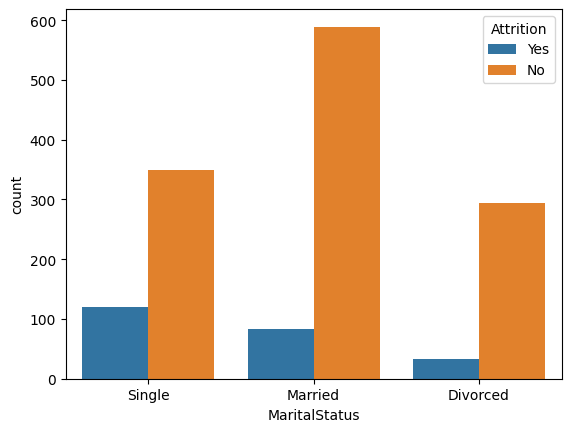

In [20]:
sns.countplot(x="MaritalStatus",
              hue="Attrition",
              data=df)

plt.show()

Correlation Heatmap

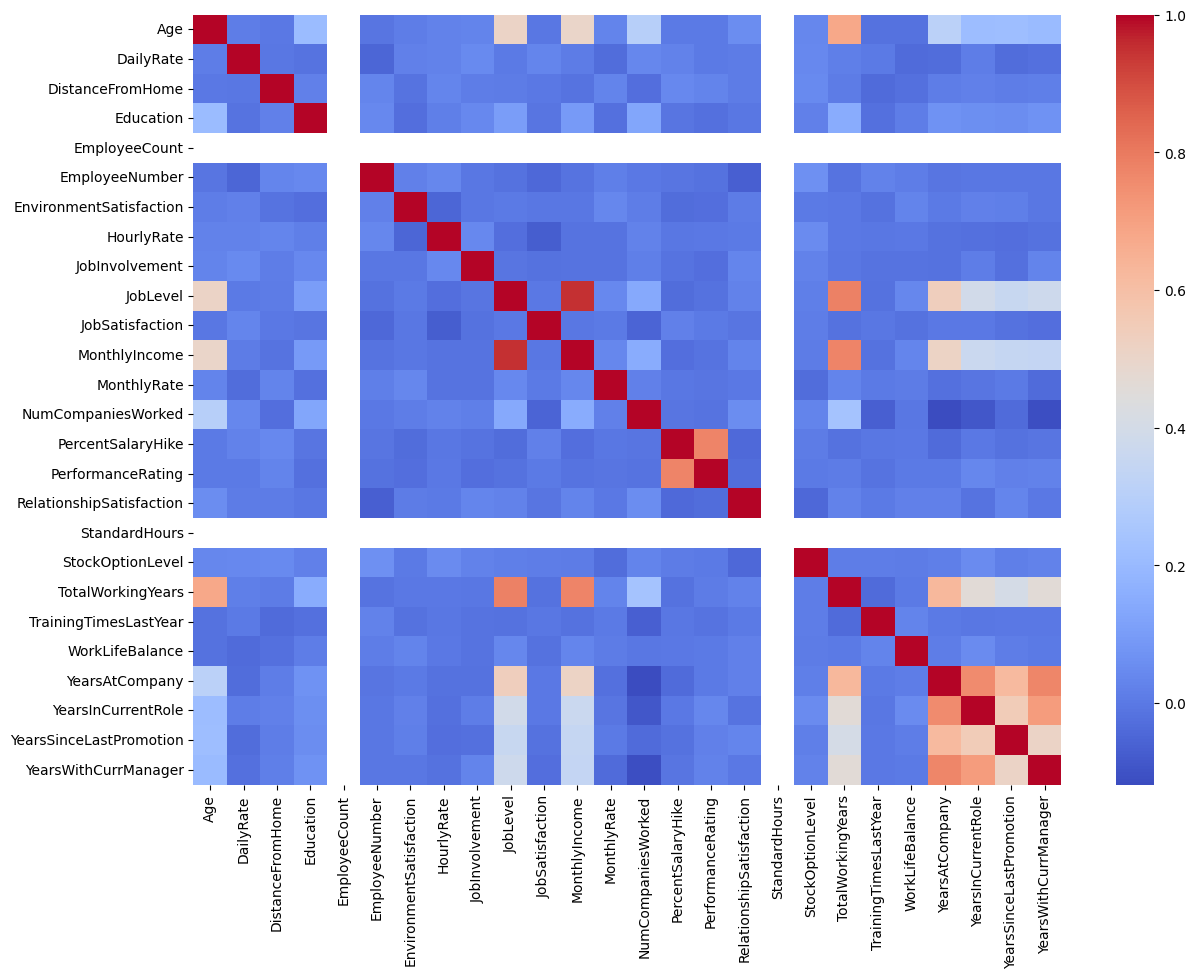

In [21]:
plt.figure(figsize=(14,10))

sns.heatmap(df.corr(numeric_only=True),
            cmap="coolwarm")

plt.show()

Data Processing

In [22]:
from sklearn.preprocessing import LabelEncoder

In [23]:
le = LabelEncoder()

In [24]:
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = le.fit_transform(df[col])

In [25]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,2,1102,2,1,2,1,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,0,1,279,1,8,1,1,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,1,2,1373,1,2,2,4,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,0,1,1392,1,3,4,1,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,0,2,591,1,2,1,3,1,7,...,4,80,1,6,3,3,2,2,2,2


Build Machine Learning Model

Target variable

Attrition

In [26]:
X = df.drop("Attrition", axis=1)

y = df["Attrition"]

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Logistic Regression

In [28]:
from sklearn.linear_model import LogisticRegression

In [29]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [30]:
y_pred = model.predict(X_test)

Accuracy

In [31]:
from sklearn.metrics import accuracy_score

In [32]:
accuracy = accuracy_score(y_test,y_pred)

print(accuracy)

0.8605442176870748


Confusion Matrix

In [33]:
from sklearn.metrics import confusion_matrix

In [34]:
cm = confusion_matrix(y_test,y_pred)

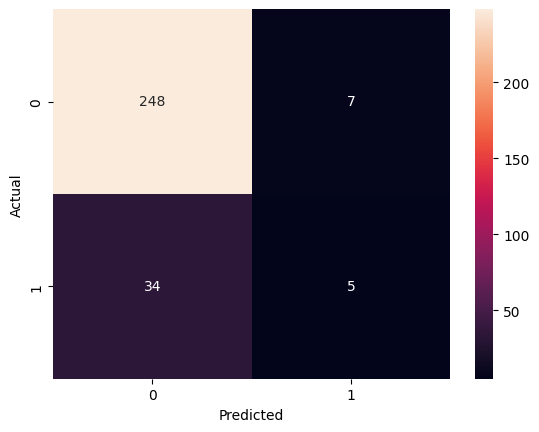

In [35]:
sns.heatmap(cm,
            annot=True,
            fmt="d")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [36]:
from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.88      0.97      0.92       255
           1       0.42      0.13      0.20        39

    accuracy                           0.86       294
   macro avg       0.65      0.55      0.56       294
weighted avg       0.82      0.86      0.83       294



SHAP Analysis

In [37]:
!pip install shap

In [38]:
import shap

In [39]:
explainer = shap.Explainer(model, X_train)

In [40]:
shap_values = explainer(X_test)

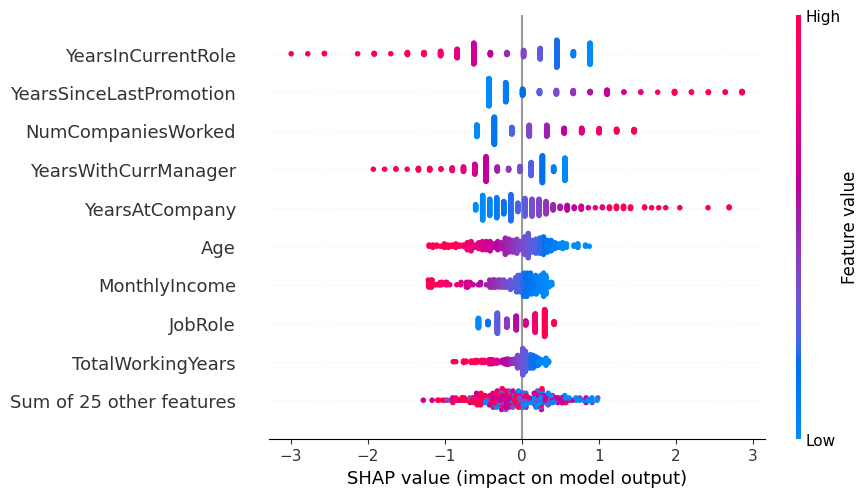

In [41]:
shap.plots.beeswarm(shap_values)

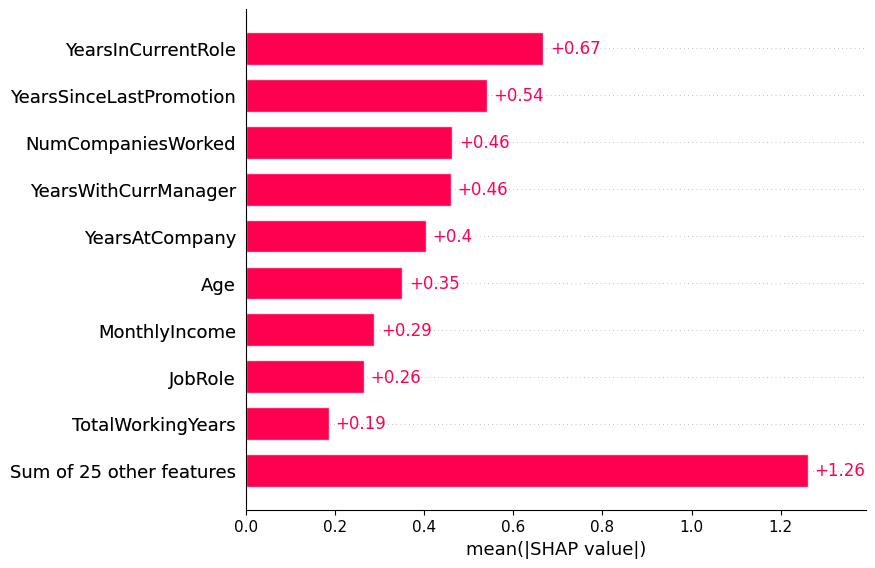

In [42]:
shap.plots.bar(shap_values)

Interpretation:

Features at the top have the greatest impact on attrition predictions.

Save Cleaned Data

In [43]:
df.to_csv("HR_Cleaned.csv", index=False)

In [44]:
from google.colab import files

files.download("HR_Cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>